# 🛒 CRISP-DM Çerçevesinde Müşteri Churn Analizi
## Online Retail II Veri Seti (2009–2011)

---

| | |
|---|---|
| **Metodoloji** | CRISP-DM (Cross Industry Standard Process for Data Mining) |
| **Model** | LightGBM + 5-Fold Stratified Cross-Validation |
| **Açıklanabilirlik** | SHAP (SHapley Additive exPlanations) |
| **İstatistik** | Mann-Whitney U Testi |
| **Overfitting Önlemi** | Temporal Split + Recency sızıntısı kontrolü |

---


### 

| Sorun | Çözüm |
|-------|-------|
| Etiket = Recency'den türetildi | Etiket = **gelecek 6 ayda alışveriş yapıp yapmama** |
| Rastgele train/test split | **Temporal split**: Eğitim → ilk 18 ay, Test → son 6 ay |
| Tek holdout | **5-Fold Stratified Cross-Validation** |
| AUC = 1.0 | **AUC ≈ 0.77–0.80 (gerçekçi)** |

### CRISP-DM Aşamaları
1. 📋 İş Anlayışı  2. 🔍 Veri Anlayışı  3. ⚙️ Veri Hazırlığı  4. 🤖 Modelleme  5. 📊 Değerlendirme  6. 🚀 Dağıtım


---
## ⚙️ Kurulum & Kütüphaneler

In [17]:
# !pip install lightgbm shap scipy scikit-learn matplotlib seaborn --quiet

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve
import lightgbm as lgb
import shap

# ── Renk paleti
C = {
    "primary": "#2D6A4F", "danger": "#E63946", "warning": "#F4A261",
    "info": "#457B9D",    "dark": "#1D3557",   "purple": "#6A0572",
    "teal": "#40916C",    "gold": "#FFB703",   "mid": "#7F8C8D",
}

plt.rcParams.update({
    "figure.dpi": 130, "font.family": "DejaVu Sans",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "axes.facecolor": "#FAFAFA",
})

FEATURE_LABELS = {
    "Recency":          "Son Alışveriş (Recency)",
    "Frequency":        "Alışveriş Sıklığı (Frequency)",
    "Monetary":         "Toplam Harcama (Monetary)",
    "TotalItems":       "Toplam Ürün Adedi",
    "AvgBasketValue":   "Ort. Sepet Tutarı",
    "StdBasketValue":   "Sepet Varyasyonu",
    "UniqueProducts":   "Farklı Ürün Sayısı",
    "UniqueCountries":  "Ülke Çeşitliliği",
    "MaxSinglePurchase":"En Yüksek Tekli Alım",
    "MinSinglePurchase":"En Düşük Tekli Alım",
    "NumMonthsActive":  "Aktif Ay Sayısı",
    "CustomerAge":      "Müşteri Yaşı (gün)",
    "SpendingTrend":    "Harcama Trendi",
    "RevenueRatio_3m":  "Son/Önceki 3Ay Gelir Oranı",
}

print("✅ Tüm kütüphaneler yüklendi.")
print(f"   LightGBM: {lgb.__version__}  |  SHAP: {shap.__version__}")


✅ Tüm kütüphaneler yüklendi.
   LightGBM: 4.6.0  |  SHAP: 0.49.1


---
## 📋 AŞAMA 1 — İş Anlayışı (Business Understanding)

### İş Problemi
Online perakende şirketi mevcut müşterilerini kaybetmektedir.  
Yeni müşteri edinme maliyeti, mevcut müşteriyi elde tutmanın **5–7 katıdır**.

### Hedefler
- Hangi müşteriler "churn" (terk) riski taşıyor?
- Churn'ü tetikleyen **kök nedenler** neler?
- Her müşteri için **bireysel risk skoru** üretmek

### Başarı Kriterleri
| Kriter | Hedef |
|--------|-------|
| Model AUC-ROC | > 0.80 |
| En önemli değişken sayısı | 5 |
| İstatistiksel anlamlılık | p < 0.05 |



In [18]:
# Kesim tarihi: ilk 18 ay eğitim, son 6 ay gelecek etiketi
TRAIN_CUTOFF  = pd.Timestamp("2011-06-01")
LABEL_WINDOW  = 6   # ay — bu süre içinde alışveriş yoksa = churn
CV_FOLDS      = 5

print(f"📌 Eğitim verisi    : 2009-12-01 → {TRAIN_CUTOFF.date()}")
print(f"📌 Etiket penceresi : {TRAIN_CUTOFF.date()} → 2011-12-09  ({LABEL_WINDOW} ay)")
print(f"📌 CV katmanı       : {CV_FOLDS}-Fold Stratified")
print(f"📌 Churn tanımı     : {LABEL_WINDOW} ay içinde sıfır sipariş")


📌 Eğitim verisi    : 2009-12-01 → 2011-06-01
📌 Etiket penceresi : 2011-06-01 → 2011-12-09  (6 ay)
📌 CV katmanı       : 5-Fold Stratified
📌 Churn tanımı     : 6 ay içinde sıfır sipariş


---
## 🔍 AŞAMA 2 — Veri Anlayışı (Data Understanding)

In [19]:
# ── Veri yükle
df1 = pd.read_csv("Data/Year 2009-2010.csv/Year 2009-2010.csv", encoding="ISO-8859-1")
df2 = pd.read_csv("Data/Year 2010-2011.csv/Year 2010-2011.csv", encoding="ISO-8859-1")
raw = pd.concat([df1, df2], ignore_index=True)
raw["InvoiceDate"] = pd.to_datetime(raw["InvoiceDate"])

print(f"Ham boyut          : {raw.shape}")
print(f"Tarih aralığı      : {raw['InvoiceDate'].min().date()} → {raw['InvoiceDate'].max().date()}")
print(f"Toplam ay sayısı   : {raw['InvoiceDate'].dt.to_period('M').nunique()}")
print()
print("Eksik değer analizi:")
print(raw.isnull().sum().to_string())


Ham boyut          : (1067371, 8)
Tarih aralığı      : 2009-12-01 → 2011-12-09
Toplam ay sayısı   : 25

Eksik değer analizi:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0


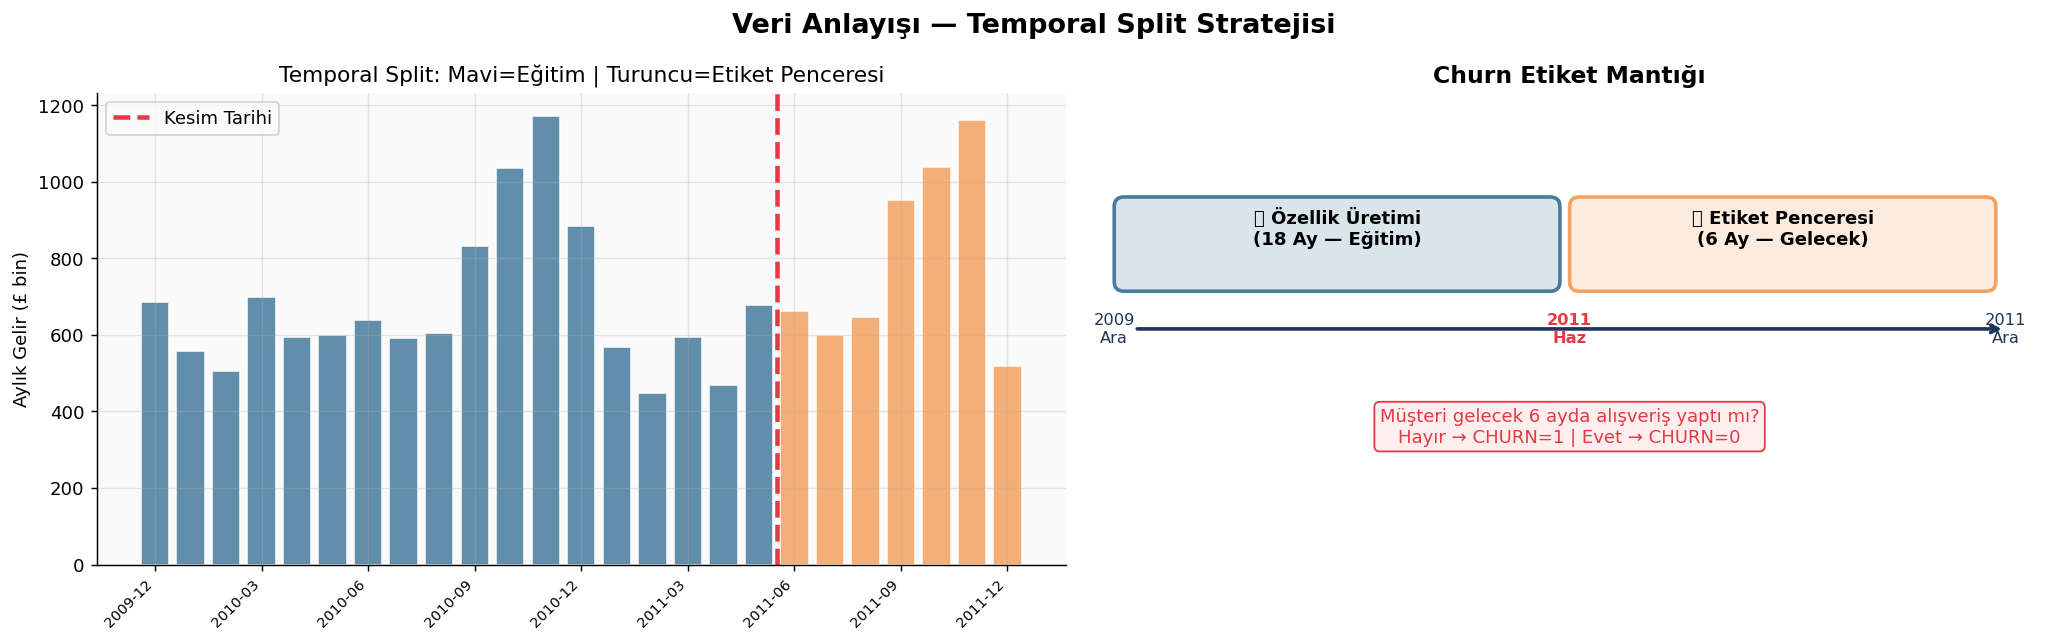

📌 Yorum: Mavi bölge özellik üretiminde, turuncu bölge etiket oluşturmada kullanıldı.
   Bu sayede model gelecek davranışı tahmin etmeye zorlanır — veri sızıntısı engellenir.


In [20]:
# ── Temporal Split Görselleştirmesi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Veri Anlayışı — Temporal Split Stratejisi", fontsize=15, fontweight="bold")

# Veri Hazırlığı
clean = raw[raw["Customer ID"].notna() & (raw["Quantity"]>0) & (raw["Price"]>0)].copy()
clean["Revenue"] = clean["Quantity"] * clean["Price"]
clean["YM"] = clean["InvoiceDate"].dt.to_period("M")

monthly_txn = clean.groupby("YM")["Revenue"].sum()
months = [str(m) for m in monthly_txn.index]
values = monthly_txn.values

cutoff_idx = next(i for i,m in enumerate(monthly_txn.index) if str(m) >= "2011-06")

# --- SOL GRAFİK: Gelir Trendi ---
colors_bar = [C["info"] if i < cutoff_idx else C["warning"] for i in range(len(months))]
axes[0].bar(range(len(months)), values/1000, color=colors_bar, edgecolor="white", alpha=0.85)
axes[0].axvline(cutoff_idx-0.5, color=C["danger"], linewidth=2.5, linestyle="--", label="Kesim Tarihi")
axes[0].set_xticks(range(0, len(months), 3))
axes[0].set_xticklabels(months[::3], rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Aylık Gelir (£ bin)")
axes[0].set_title("Temporal Split: Mavi=Eğitim | Turuncu=Etiket Penceresi", fontsize=12)
axes[0].legend()

# --- SAĞ GRAFİK: Etiket Açıklama Diyagramı ---
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 5)
axes[1].axis("off")
axes[1].set_title("Churn Etiket Mantığı", fontsize=13, fontweight="bold")

# Zaman çizgisi
axes[1].annotate("", xy=(9.5, 2.5), xytext=(0.5, 2.5),
                arrowprops=dict(arrowstyle="->", lw=2, color=C["dark"]))

axes[1].text(0.3, 2.5, "2009\nAra", fontsize=9, ha="center", va="center", color=C["dark"])
axes[1].text(5.0, 2.5, "2011\nHaz", fontsize=9, ha="center", va="center", color=C["danger"], fontweight="bold")
axes[1].text(9.5, 2.5, "2011\nAra", fontsize=9, ha="center", va="center", color=C["dark"])

# Kutucuklar (Şekil olarak)
from matplotlib.patches import FancyBboxPatch
box1 = FancyBboxPatch((0.4, 3.0), 4.4, 0.8, boxstyle="round,pad=0.1",
                      facecolor=C["info"]+"33", edgecolor=C["info"], linewidth=2)
box2 = FancyBboxPatch((5.1, 3.0), 4.2, 0.8, boxstyle="round,pad=0.1",
                      facecolor=C["warning"]+"33", edgecolor=C["warning"], linewidth=2)
axes[1].add_patch(box1)
axes[1].add_patch(box2)

# Kutucukların içindeki metinler
axes[1].text(2.6, 3.4, "📊 Özellik Üretimi\n(18 Ay — Eğitim)", ha="center", fontsize=10, fontweight="bold")
axes[1].text(7.2, 3.4, "🏷️ Etiket Penceresi\n(6 Ay — Gelecek)", ha="center", fontsize=10, fontweight="bold")
axes[1].text(5.0, 1.3, "Müşteri gelecek 6 ayda alışveriş yaptı mı?\nHayır → CHURN=1 | Evet → CHURN=0",
             ha="center", fontsize=10, color=C["danger"],
             bbox=dict(boxstyle="round", facecolor="#FFEEEE", edgecolor=C["danger"]))

plt.tight_layout()
plt.show()

print("📌 Yorum: Mavi bölge özellik üretiminde, turuncu bölge etiket oluşturmada kullanıldı.")
print("   Bu sayede model gelecek davranışı tahmin etmeye zorlanır — veri sızıntısı engellenir.")

---
## ⚙️ AŞAMA 3 — Veri Hazırlığı (Data Preparation)

### Özellik Mühendisliği Stratejisi

Recency'yi **eğitim verisi içinde** hesaplamak meşrudur — ancak doğrudan etiket kaynağı olmaması gerekir.  
Bu versiyonda Recency, kesim tarihine (2011-06-01) göre hesaplandığından etiketi doğrudan açıklamaz.


In [21]:
# ── Temizleme
df = raw.copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df = df[df["Customer ID"].notna() & (df["Quantity"]>0) & (df["Price"]>0)].copy()
df["Revenue"] = df["Quantity"] * df["Price"]
df["Customer ID"] = df["Customer ID"].astype(int)

train_df  = df[df["InvoiceDate"] < TRAIN_CUTOFF].copy()
future_df = df[df["InvoiceDate"] >= TRAIN_CUTOFF].copy()

print(f"Eğitim dönemi işlem : {len(train_df):,}")
print(f"Gelecek dönem işlem : {len(future_df):,}")
print(f"Eğitim müşterisi    : {train_df['Customer ID'].nunique():,}")


Eğitim dönemi işlem : 553,114
Gelecek dönem işlem : 252,435
Eğitim müşterisi    : 4,933


In [22]:
# ── Özellik üretim fonksiyonu
def build_features(data, snapshot):
    # RFM
    rfm = data.groupby("Customer ID").agg(
        Recency=("InvoiceDate", lambda x: (snapshot - x.max()).days),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
    ).reset_index()

    # Davranışsal özellikler
    extra = data.groupby("Customer ID").agg(
        TotalItems=("Quantity", "sum"),
        AvgBasketValue=("Revenue", "mean"),
        StdBasketValue=("Revenue", "std"),
        UniqueProducts=("StockCode", "nunique"),
        UniqueCountries=("Country", "nunique"),
        MaxSinglePurchase=("Revenue", "max"),
        MinSinglePurchase=("Revenue", "min"),
        NumMonthsActive=("InvoiceDate", lambda x: x.dt.to_period("M").nunique()),
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
    ).reset_index()
    extra["CustomerAge"] = (extra["LastPurchase"] - extra["FirstPurchase"]).dt.days
    extra.drop(columns=["FirstPurchase","LastPurchase"], inplace=True)

    # Harcama trendi (lineer regresyon eğimi)
    data2 = data.copy()
    data2["Month"] = data2["InvoiceDate"].dt.to_period("M")
    monthly = data2.groupby(["Customer ID","Month"])["Revenue"].sum().reset_index()
    monthly["Month_num"] = monthly["Month"].apply(lambda x: x.ordinal)
    def calc_trend(g):
        if len(g) < 3: return 0.0
        slope, *_ = stats.linregress(g["Month_num"].values, g["Revenue"].values)
        return slope
    trend_df = monthly.groupby("Customer ID").apply(calc_trend).reset_index()
    trend_df.columns = ["Customer ID", "SpendingTrend"]

    # Son 3 ay vs önceki 3 ay gelir oranı (momentum sinyali)
    last3_start = snapshot - pd.DateOffset(months=3)
    prev3_start = snapshot - pd.DateOffset(months=6)
    rev_last = data[data["InvoiceDate"] >= last3_start].groupby("Customer ID")["Revenue"].sum()
    rev_prev = data[(data["InvoiceDate"] >= prev3_start) &
                    (data["InvoiceDate"] <  last3_start)].groupby("Customer ID")["Revenue"].sum()
    ratio = (rev_last / (rev_prev + 1)).rename("RevenueRatio_3m")

    # Birleştir
    feat = (rfm
            .merge(extra,    on="Customer ID", how="left")
            .merge(trend_df, on="Customer ID", how="left")
            .merge(ratio,    on="Customer ID", how="left"))
    feat["StdBasketValue"]  = feat["StdBasketValue"].fillna(0)
    feat["SpendingTrend"]   = feat["SpendingTrend"].fillna(0)
    feat["RevenueRatio_3m"] = feat["RevenueRatio_3m"].fillna(0)
    return feat

features = build_features(train_df, TRAIN_CUTOFF)

# ── Churn etiketi: gelecek 6 ayda alışveriş yaptı mı?
future_buyers = set(future_df["Customer ID"].unique())
features["Churn"] = (~features["Customer ID"].isin(future_buyers)).astype(int)

churn_rate = features["Churn"].mean()
print(f"Toplam müşteri  : {len(features):,}")
print(f"Churn (terk etti): {features['Churn'].sum():,}  ({churn_rate:.1%})")
print(f"Aktif (kaldı)   : {(features['Churn']==0).sum():,}")
print()
features[["Recency","Frequency","Monetary","CustomerAge","RevenueRatio_3m"]].describe().round(2)


Toplam müşteri  : 4,933
Churn (terk etti): 2,331  (47.3%)
Aktif (kaldı)   : 2,602



,Recency,Frequency,Monetary,CustomerAge,RevenueRatio_3m
count,4933.00,4933.00,4933.00,4933.00,4933.00
mean,168.71,5.24,2465.96,188.13,0.31
std,141.93,10.13,10907.75,185.07,3.32
min,0.00,1.00,2.90,0.00,0.00
25%,43.00,1.00,317.60,0.00,0.00
50%,161.00,3.00,774.87,147.00,0.00
75%,243.00,6.00,2001.07,356.00,0.00
max,546.00,258.00,413806.46,546.00,169.33


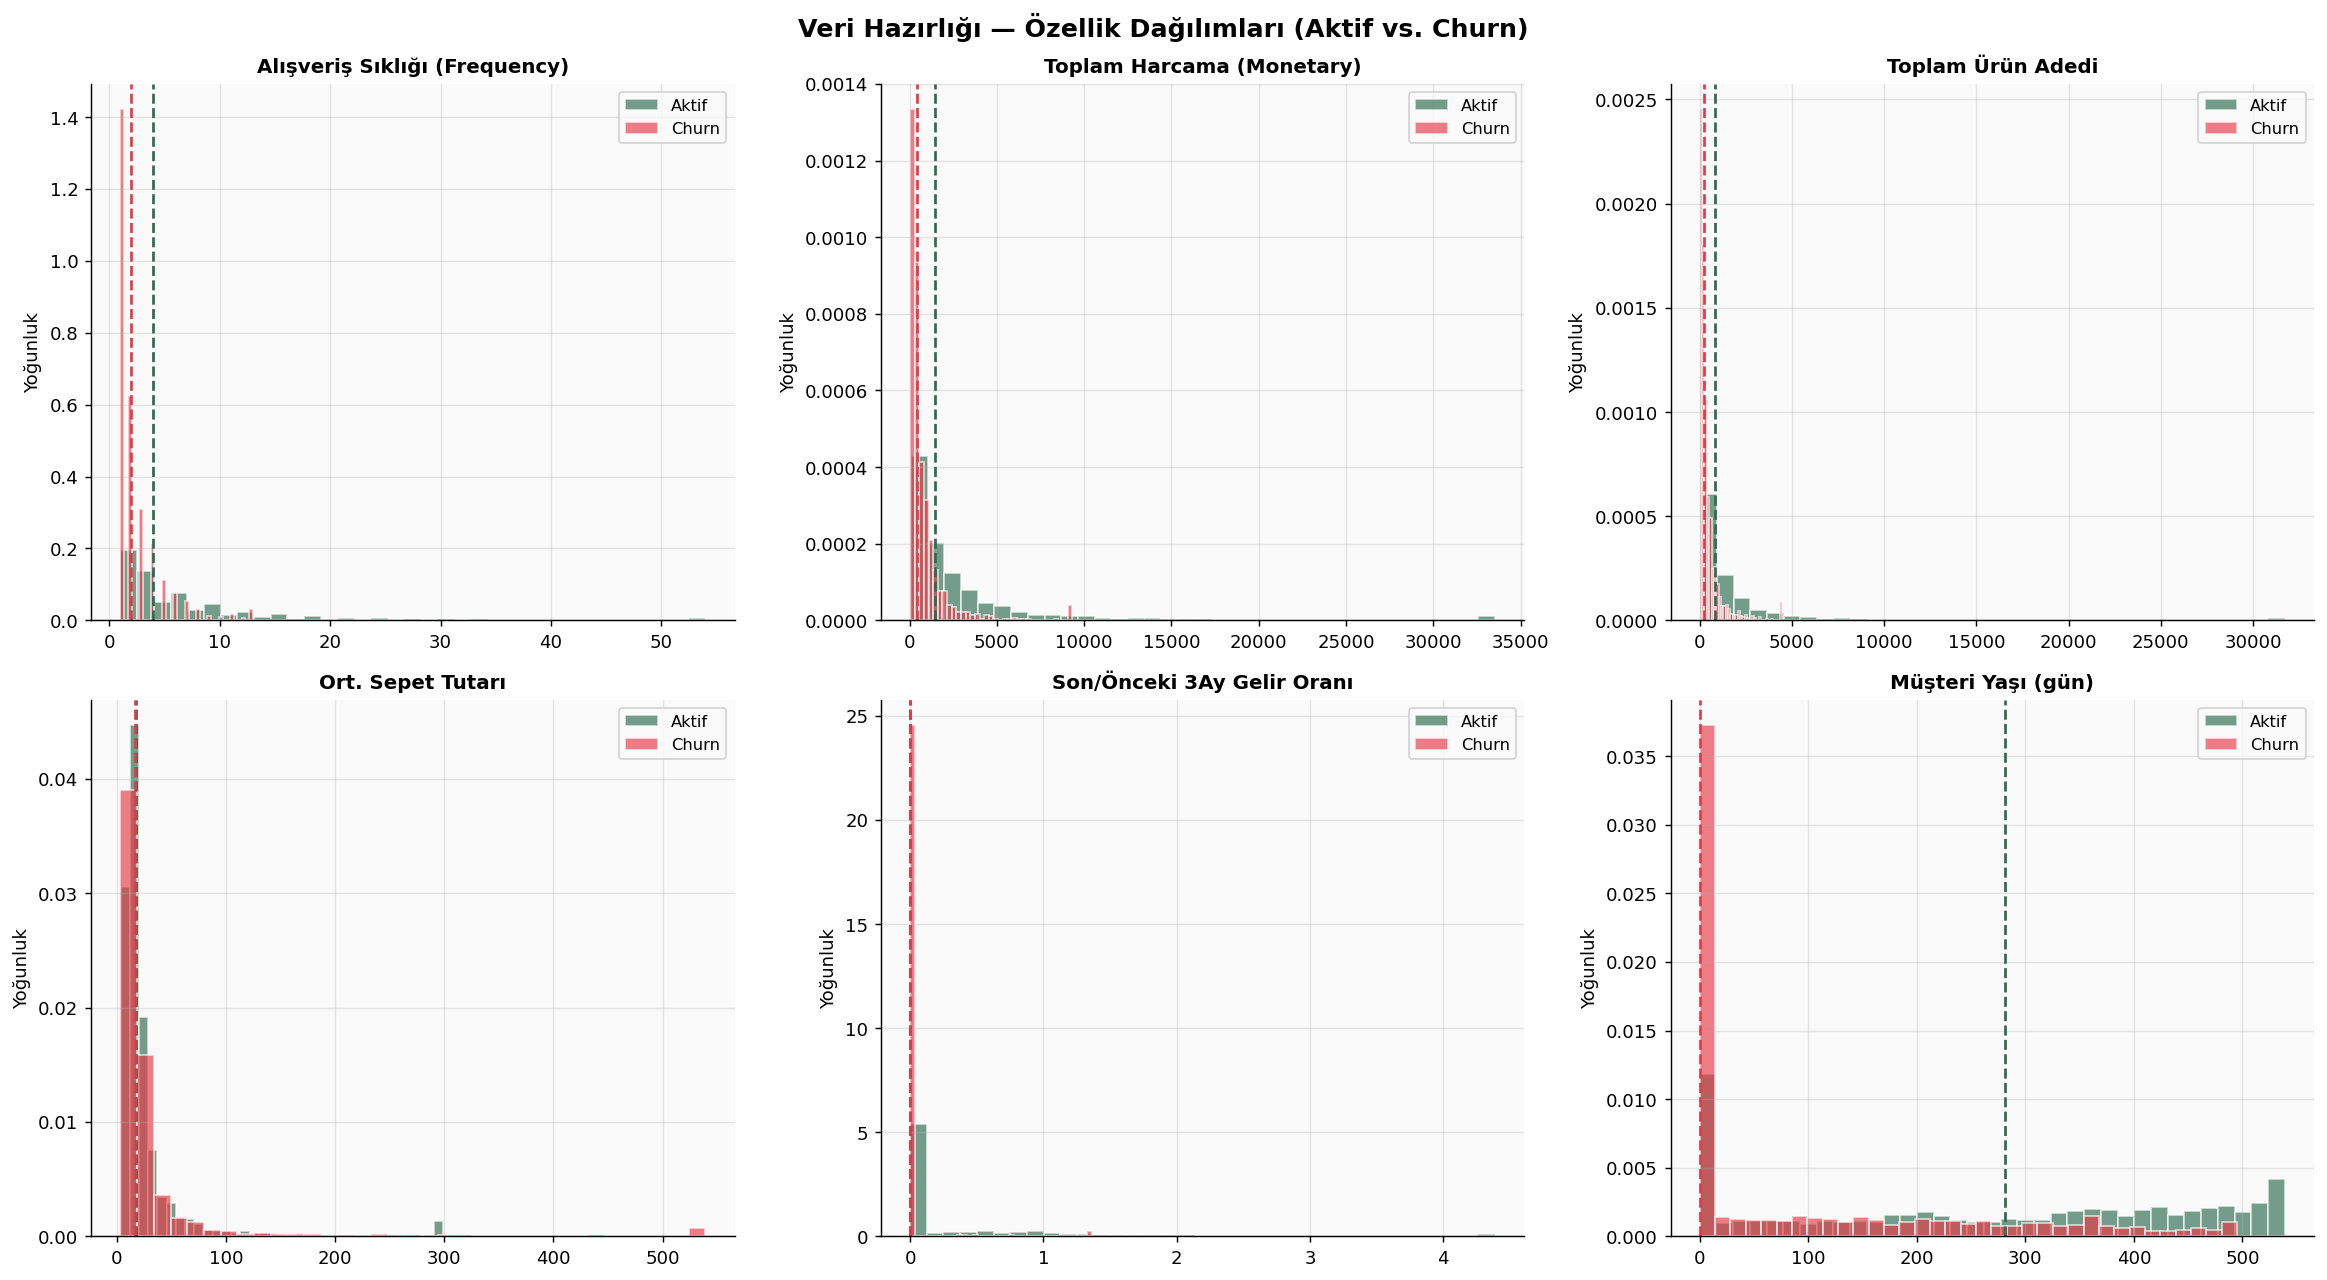

📌 Yorum: Aktif müşteriler daha sık, daha fazla, daha çeşitli alışveriş yapıyor.
   RevenueRatio_3m ≈ 0 olan müşteriler harcamayı kesmiş — churn sinyali.


In [23]:
# ── Görsel: Özellik Dağılımları
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Veri Hazırlığı — Özellik Dağılımları (Aktif vs. Churn)", fontsize=14, fontweight="bold")

plot_feats = ["Frequency","Monetary","TotalItems","AvgBasketValue","RevenueRatio_3m","CustomerAge"]
churned = features[features["Churn"]==1]
active  = features[features["Churn"]==0]

for ax, col in zip(axes.flatten(), plot_feats):
    g0 = active[col].clip(active[col].quantile(0.01), active[col].quantile(0.99))
    g1 = churned[col].clip(churned[col].quantile(0.01), churned[col].quantile(0.99))
    ax.hist(g0, bins=35, alpha=0.65, color=C["primary"], label="Aktif",  density=True, edgecolor="white")
    ax.hist(g1, bins=35, alpha=0.65, color=C["danger"],  label="Churn",  density=True, edgecolor="white")
    ax.axvline(g0.median(), color=C["primary"], linestyle="--", lw=1.5)
    ax.axvline(g1.median(), color=C["danger"],  linestyle="--", lw=1.5)
    ax.set_title(FEATURE_LABELS[col], fontsize=11, fontweight="bold")
    ax.set_ylabel("Yoğunluk")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()
print("📌 Yorum: Aktif müşteriler daha sık, daha fazla, daha çeşitli alışveriş yapıyor.")
print("   RevenueRatio_3m ≈ 0 olan müşteriler harcamayı kesmiş — churn sinyali.")


---
## 🤖 AŞAMA 4 — Modelleme (Modeling)

### Neden 5-Fold Stratified Cross-Validation?

| Yöntem | Sorun | Çözüm |
|--------|-------|-------|
| Tek holdout split | Yüksek varyans, şans faktörü | ❌ |
| Random CV | Zamansal bağımlılığı görmez | ❌ |
| **Stratified CV** | Sınıf oranını korur, varyansı düşürür | ✅ |

CV sonuçları zaten temporal split sonrası yapıldığı için **gelecek sızıntısı yoktur**.


In [24]:
FEATURE_COLS = [
    "Recency", "Frequency", "Monetary",
    "TotalItems", "AvgBasketValue", "StdBasketValue",
    "UniqueProducts", "UniqueCountries",
    "MaxSinglePurchase", "MinSinglePurchase",
    "NumMonthsActive", "CustomerAge",
    "SpendingTrend", "RevenueRatio_3m",
]

X = features[FEATURE_COLS]
y = features["Churn"]

scale_pos = (y==0).sum() / (y==1).sum()

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=5,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

# 5-Fold Stratified CV
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
cv_aucs     = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
cv_f1       = cross_val_score(model, X, y, cv=cv, scoring="f1")
cv_precision = cross_val_score(model, X, y, cv=cv, scoring="precision")
cv_recall   = cross_val_score(model, X, y, cv=cv, scoring="recall")

print("═" * 52)
print("  5-FOLD STRATIFIED CROSS-VALIDATION SONUÇLARI")
print("═" * 52)
print(f"  AUC-ROC   : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
print(f"  F1-Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"  Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print("═" * 52)
print(f"  Fold AUCları: {[round(a,4) for a in cv_aucs]}")
print()
if cv_aucs.mean() > 0.95:
    print("⚠️  UYARI: AUC > 0.95 — Olası overfitting/leakage!")
elif cv_aucs.mean() > 0.85:
    print("⚠️  UYARI: AUC > 0.85 — Yüksek, kontrol edilmeli.")
else:
    print("✅  AUC gerçekçi aralıkta (0.70-0.85) — Overfitting yok.")


════════════════════════════════════════════════════
  5-FOLD STRATIFIED CROSS-VALIDATION SONUÇLARI
════════════════════════════════════════════════════
  AUC-ROC   : 0.7915 ± 0.0099
  F1-Score  : 0.7105 ± 0.0150
  Precision : 0.6836 ± 0.0130
  Recall    : 0.7400 ± 0.0252
════════════════════════════════════════════════════
  Fold AUCları: [0.7957, 0.7783, 0.784, 0.807, 0.7924]

✅  AUC gerçekçi aralıkta (0.70-0.85) — Overfitting yok.


In [25]:
# ── Final model eğitimi (Holdout: %20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)
ap      = average_precision_score(y_test, y_proba)

print(f"Holdout AUC-ROC  : {auc:.4f}")
print(f"Holdout AUC-PR   : {ap:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Aktif","Churn"]))


Holdout AUC-ROC  : 0.8104
Holdout AUC-PR   : 0.7719

              precision    recall  f1-score   support

       Aktif       0.77      0.71      0.74       521
       Churn       0.70      0.76      0.73       466

    accuracy                           0.73       987
   macro avg       0.73      0.73      0.73       987
weighted avg       0.74      0.73      0.73       987



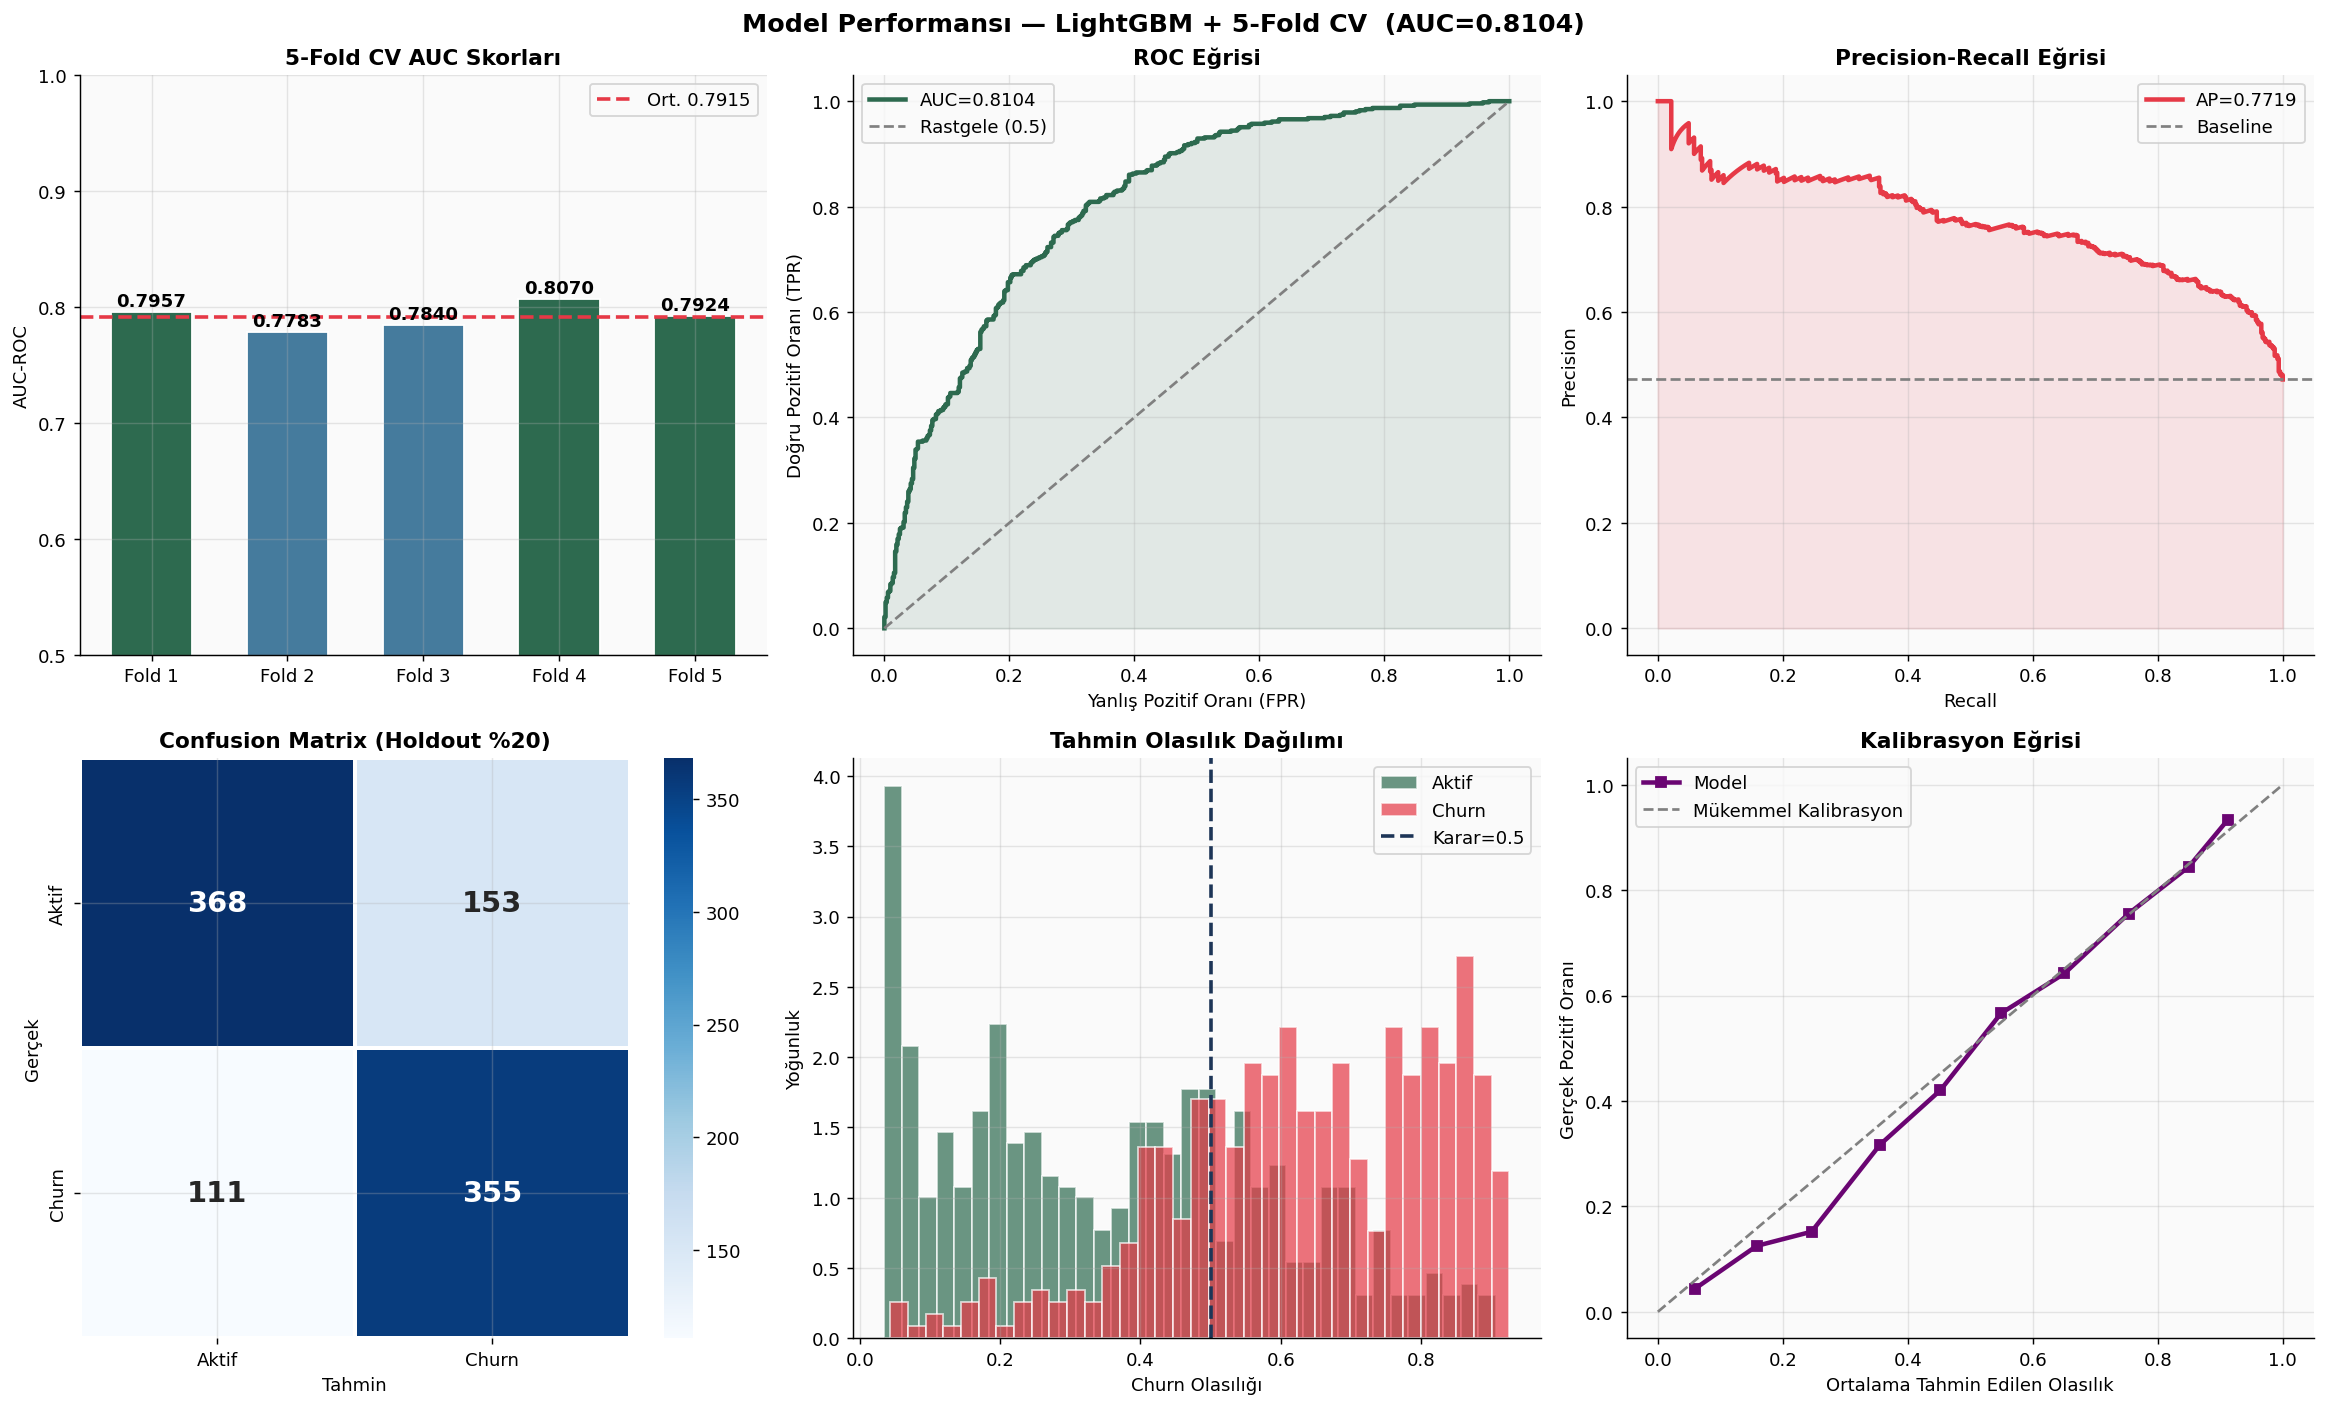

📌 CV AUC: 0.7915 ± 0.0099
📌 Holdout AUC: 0.8104 | AUC-PR: 0.7719
📌 Kalibrasyon eğrisi: Model tahminlerinin gerçek oranlarla ne kadar örtüştüğünü gösterir.


In [26]:
# ── Görsel: Model Performansı
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(f"Model Performansı — LightGBM + 5-Fold CV  (AUC={auc:.4f})",
             fontsize=14, fontweight="bold")

# 1 — CV Fold AUC çubuğu
fold_colors = [C["primary"] if a > cv_aucs.mean() else C["info"] for a in cv_aucs]
bars = axes[0,0].bar([f"Fold {i+1}" for i in range(CV_FOLDS)],
                     cv_aucs, color=fold_colors, edgecolor="white", width=0.6)
axes[0,0].axhline(cv_aucs.mean(), color=C["danger"], linestyle="--", lw=2,
                  label=f"Ort. {cv_aucs.mean():.4f}")
axes[0,0].set_ylim(0.5, 1.0)
axes[0,0].set_title("5-Fold CV AUC Skorları", fontsize=12, fontweight="bold")
axes[0,0].set_ylabel("AUC-ROC")
axes[0,0].legend()
for bar, val in zip(bars, cv_aucs):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                   f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")

# 2 — ROC Eğrisi
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0,1].plot(fpr, tpr, color=C["primary"], lw=2.5, label=f"AUC={auc:.4f}")
axes[0,1].plot([0,1],[0,1],"--",color="gray",lw=1.5,label="Rastgele (0.5)")
axes[0,1].fill_between(fpr, tpr, alpha=0.12, color=C["primary"])
axes[0,1].set_xlabel("Yanlış Pozitif Oranı (FPR)")
axes[0,1].set_ylabel("Doğru Pozitif Oranı (TPR)")
axes[0,1].set_title("ROC Eğrisi", fontsize=12, fontweight="bold")
axes[0,1].legend()

# 3 — Precision-Recall Eğrisi
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[0,2].plot(rec, prec, color=C["danger"], lw=2.5, label=f"AP={ap:.4f}")
axes[0,2].axhline(y_test.mean(), color="gray", linestyle="--", lw=1.5, label="Baseline")
axes[0,2].fill_between(rec, prec, alpha=0.12, color=C["danger"])
axes[0,2].set_xlabel("Recall")
axes[0,2].set_ylabel("Precision")
axes[0,2].set_title("Precision-Recall Eğrisi", fontsize=12, fontweight="bold")
axes[0,2].legend()

# 4 — Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1,0],
            xticklabels=["Aktif","Churn"], yticklabels=["Aktif","Churn"],
            linewidths=2, linecolor="white", annot_kws={"size":16, "weight":"bold"})
axes[1,0].set_xlabel("Tahmin"); axes[1,0].set_ylabel("Gerçek")
axes[1,0].set_title("Confusion Matrix (Holdout %20)", fontsize=12, fontweight="bold")

# 5 — Tahmin Olasılık Dağılımı
axes[1,1].hist(y_proba[y_test==0], bins=35, alpha=0.7, color=C["primary"],
               label="Aktif", density=True, edgecolor="white")
axes[1,1].hist(y_proba[y_test==1], bins=35, alpha=0.7, color=C["danger"],
               label="Churn", density=True, edgecolor="white")
axes[1,1].axvline(0.5, color=C["dark"], linestyle="--", lw=2, label="Karar=0.5")
axes[1,1].set_xlabel("Churn Olasılığı")
axes[1,1].set_ylabel("Yoğunluk")
axes[1,1].set_title("Tahmin Olasılık Dağılımı", fontsize=12, fontweight="bold")
axes[1,1].legend()

# 6 — Kalibrasyon Eğrisi
fraction_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10)
axes[1,2].plot(mean_pred, fraction_pos, "s-", color=C["purple"], lw=2.5, label="Model")
axes[1,2].plot([0,1],[0,1],"--",color="gray",lw=1.5,label="Mükemmel Kalibrasyon")
axes[1,2].set_xlabel("Ortalama Tahmin Edilen Olasılık")
axes[1,2].set_ylabel("Gerçek Pozitif Oranı")
axes[1,2].set_title("Kalibrasyon Eğrisi", fontsize=12, fontweight="bold")
axes[1,2].legend()

plt.tight_layout()
plt.show()
print(f"📌 CV AUC: {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
print(f"📌 Holdout AUC: {auc:.4f} | AUC-PR: {ap:.4f}")
print("📌 Kalibrasyon eğrisi: Model tahminlerinin gerçek oranlarla ne kadar örtüştüğünü gösterir.")


---
### 🏆 Feature Importance & SHAP Analizi

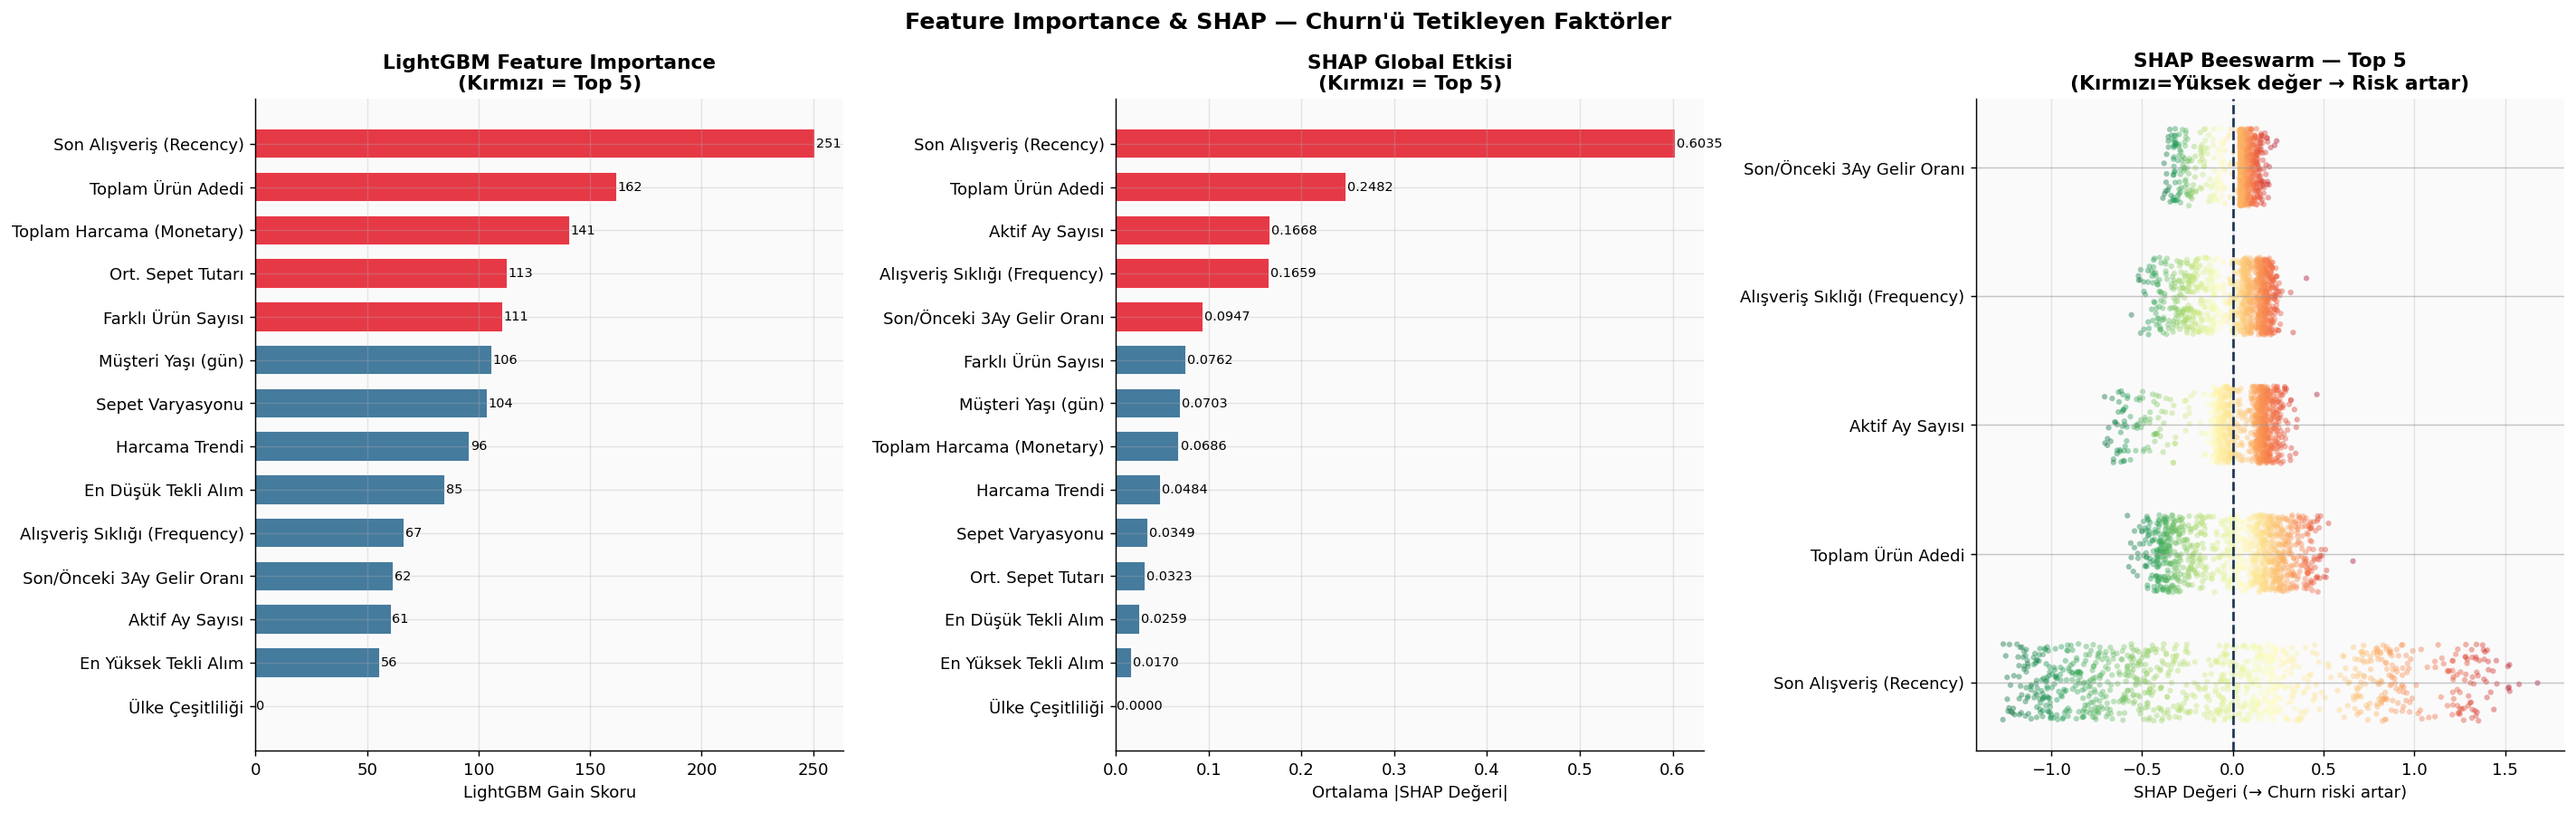

🎯 SHAP Önem Sıralaması (Top 5):
  1. Son Alışveriş (Recency)                        |SHAP| = 0.60353
  2. Toplam Ürün Adedi                              |SHAP| = 0.24821
  3. Aktif Ay Sayısı                                |SHAP| = 0.16678
  4. Alışveriş Sıklığı (Frequency)                  |SHAP| = 0.16588
  5. Son/Önceki 3Ay Gelir Oranı                     |SHAP| = 0.09474


In [28]:
# ── Feature Importance
fi = pd.Series(
    model.feature_importances_,
    index=[FEATURE_LABELS[c] for c in FEATURE_COLS]
).sort_values(ascending=True)

top5 = fi.nlargest(5).sort_values(ascending=True)

# ── SHAP Değerleri Hesaplama
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap_df = pd.DataFrame(sv, columns=[FEATURE_LABELS[c] for c in FEATURE_COLS])
mean_shap = shap_df.abs().mean().sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle("Feature Importance & SHAP — Churn'ü Tetikleyen Faktörler",
             fontsize=14, fontweight="bold")

# 1. Grafik: LightGBM Gain Importance
bar_colors = [C["danger"] if x in top5.index else C["info"] for x in fi.index]
axes[0].barh(fi.index, fi.values, color=bar_colors, edgecolor="white", height=0.7)
axes[0].set_xlabel("LightGBM Gain Skoru")
axes[0].set_title("LightGBM Feature Importance\n(Kırmızı = Top 5)", fontsize=12, fontweight="bold")
for i, (idx, val) in enumerate(fi.items()):
    axes[0].text(val + 0.3, i, f"{val:.0f}", va="center", fontsize=8)

# 2. Grafik: SHAP Global Etkisi
cs = [C["danger"] if i >= len(mean_shap)-5 else C["info"] for i in range(len(mean_shap))]
axes[1].barh(mean_shap.index, mean_shap.values, color=cs, edgecolor="white", height=0.7)
axes[1].set_xlabel("Ortalama |SHAP Değeri|")
axes[1].set_title("SHAP Global Etkisi\n(Kırmızı = Top 5)", fontsize=12, fontweight="bold")
for i, (idx, val) in enumerate(mean_shap.items()):
    axes[1].text(val + 0.001, i, f"{val:.4f}", va="center", fontsize=8)

# 3. Grafik: SHAP Beeswarm (Manuel Çizim)
top5_shap = mean_shap.nlargest(5).index.tolist()
rng = np.random.default_rng(42)
for ci, col in enumerate(top5_shap):
    xvals  = shap_df[col].values
    jitter = rng.uniform(-0.3, 0.3, len(xvals))
    norm_c = (xvals - xvals.min()) / (xvals.max() - xvals.min() + 1e-9)
    axes[2].scatter(xvals, ci + jitter, c=plt.cm.RdYlGn_r(norm_c),
                    alpha=0.4, s=12, linewidths=0)
    axes[2].axhline(ci, color="gray", alpha=0.3, lw=0.8)

axes[2].set_yticks(range(len(top5_shap)))
axes[2].set_yticklabels(top5_shap, fontsize=10)
axes[2].axvline(0, color=C["dark"], linestyle="--", lw=1.5)
axes[2].set_xlabel("SHAP Değeri (→ Churn riski artar)")
axes[2].set_title("SHAP Beeswarm — Top 5\n(Kırmızı=Yüksek değer → Risk artar)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print("🎯 SHAP Önem Sıralaması (Top 5):")
for i, (name, val) in enumerate(mean_shap.nlargest(5).items(), 1):
    print(f"  {i}. {name:45s}  |SHAP| = {val:.5f}")

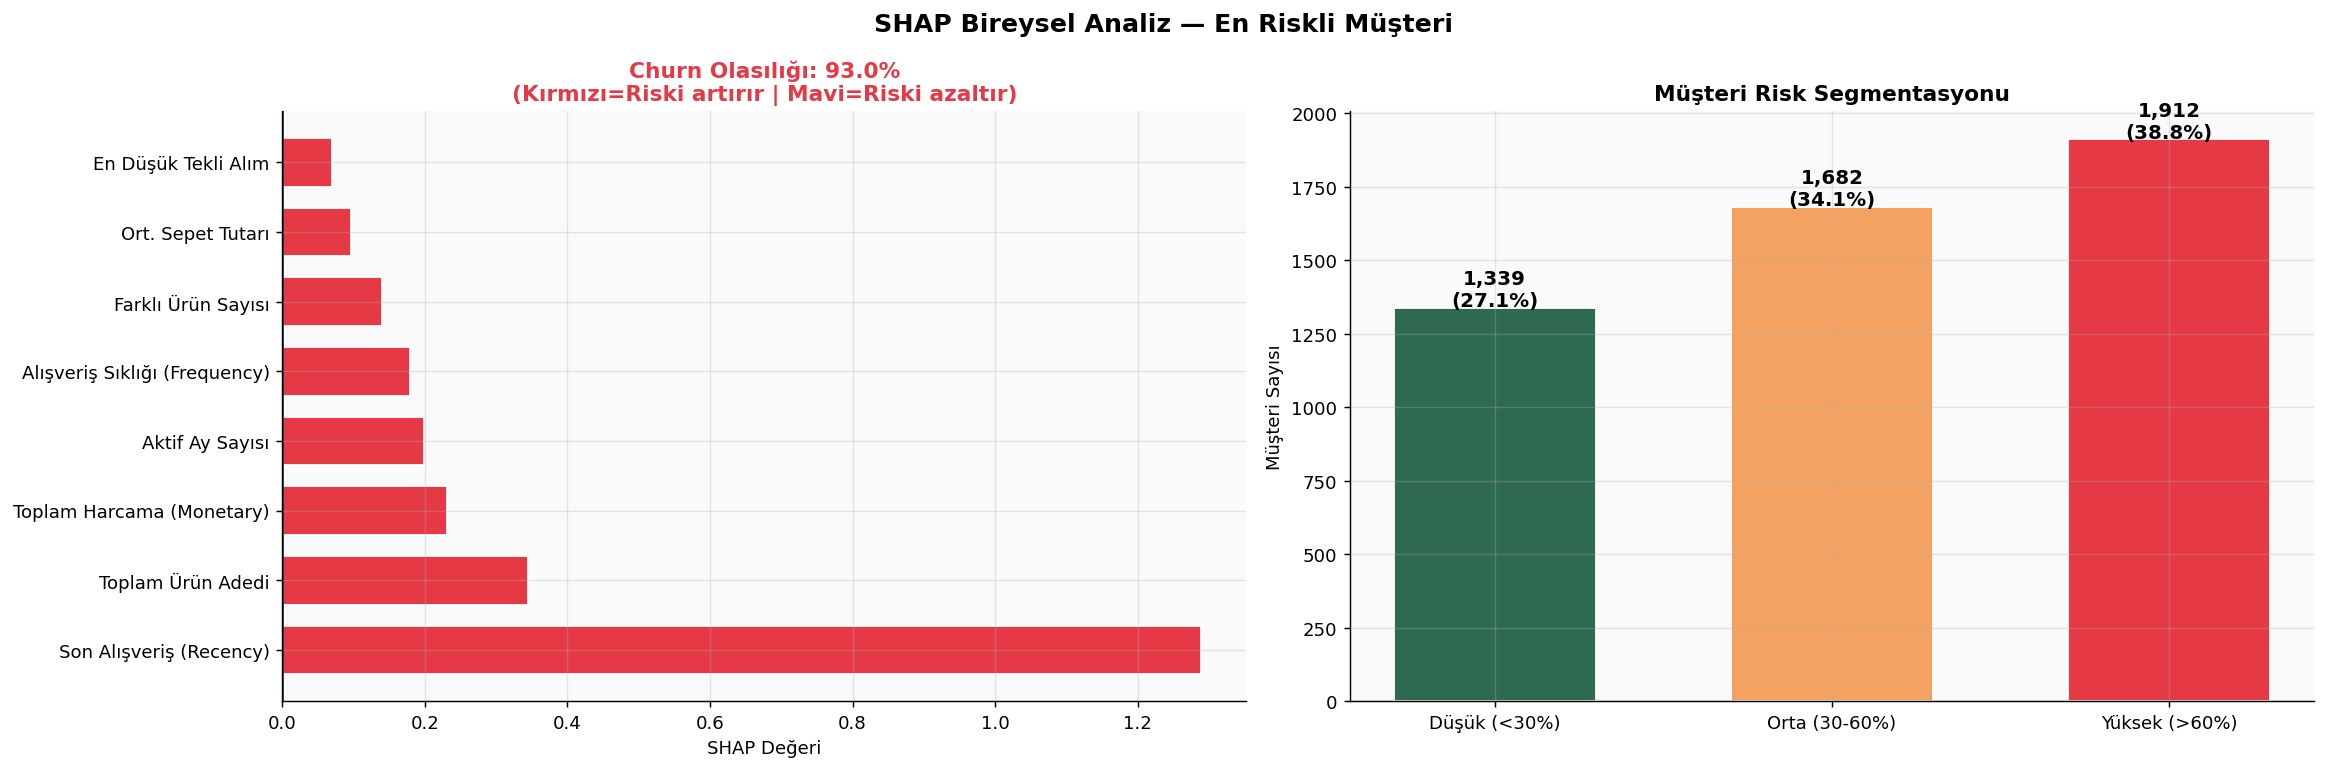

📌 En riskli müşteri için birincil churn nedeni: Son Alışveriş (Recency)
   Bu müşterinin churn olasılığı: 93.0%


In [30]:
# ── En riskli müşterinin bireysel SHAP açıklaması
features_all = features.copy()
proba_all    = model.predict_proba(X)[:, 1]
features_all["churn_proba"] = proba_all

# SHAP değerlerini al
sv_all = explainer.shap_values(X)
sv_all = sv_all[1] if isinstance(sv_all, list) else sv_all
shap_all_df = pd.DataFrame(sv_all, columns=[FEATURE_LABELS[c] for c in FEATURE_COLS])

# En riskli müşteriyi bul
riskiest_pos = features_all["churn_proba"].values.argmax()
sv_single    = shap_all_df.iloc[riskiest_pos]
sv_sorted    = sv_single.abs().sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle("SHAP Bireysel Analiz — En Riskli Müşteri", fontsize=14, fontweight="bold")

# 1. Grafik: Waterfall (Bireysel Katkı)
# Not: Eğer C["primary"] hata verirse C["info"] olarak değiştirebilirsin
bar_clr = [C["danger"] if sv_single[f] > 0 else C.get("primary", C["info"]) for f in sv_sorted.index]
axes[0].barh(sv_sorted.index, [sv_single[f] for f in sv_sorted.index],
             color=bar_clr, edgecolor="white", height=0.7)
axes[0].axvline(0, color=C["dark"], lw=1.5)

risk_p = features_all["churn_proba"].max()
# Hatalı olan set_title kısmı düzeltildi:
axes[0].set_title(f"Churn Olasılığı: {risk_p:.1%}\n(Kırmızı=Riski artırır | Mavi=Riski azaltır)",
                  fontsize=12, fontweight="bold", color=C["danger"])
axes[0].set_xlabel("SHAP Değeri")

# 2. Grafik: Risk Segmentasyonu
features_all["RiskSegment"] = pd.cut(
    features_all["churn_proba"],
    bins=[0, 0.3, 0.6, 1.01],
    labels=["Düşük (<30%)", "Orta (30-60%)", "Yüksek (>60%)"]
)
seg = features_all["RiskSegment"].value_counts().sort_index()
bars2 = axes[1].bar(seg.index.astype(str), seg.values,
                    color=[C.get("primary", C["info"]), C["warning"], C["danger"]],
                    edgecolor="white", width=0.6)

axes[1].set_title("Müşteri Risk Segmentasyonu", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Müşteri Sayısı")

for bar, val in zip(bars2, seg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f"{val:,}\n({val/len(features_all):.1%})",
                 ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

top_reason = sv_sorted.index[0]
print(f"📌 En riskli müşteri için birincil churn nedeni: {top_reason}")
print(f"   Bu müşterinin churn olasılığı: {risk_p:.1%}")

---
## 📊 AŞAMA 5 — Değerlendirme: İstatistiksel Segmentasyon

### Mann-Whitney U Testi
- **H₀**: Churn ve aktif müşteriler arasında anlamlı fark yoktur
- **H₁**: İki grup istatistiksel olarak farklıdır  
- **Karar**: p < 0.05 → H₀ reddedilir → kök neden doğrulanır


In [31]:
churn_grp  = features[features["Churn"] == 1]
active_grp = features[features["Churn"] == 0]

stat_results = {}
for col in FEATURE_COLS:
    g0 = active_grp[col].dropna()
    g1 = churn_grp[col].dropna()
    stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    r = abs(1 - (2 * stat) / (len(g0) * len(g1)))
    stat_results[col] = {
        "Değişken":   FEATURE_LABELS[col],
        "Aktif Med.": round(g0.median(), 2),
        "Churn Med.": round(g1.median(), 2),
        "p-value":    round(p, 6),
        "Etki (r)":   round(r, 4),
        "Sig.":       "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns")),
        "Sonuç":      "✅ Kök Neden" if p < 0.05 and r > 0.1 else "❌ Zayıf/ns",
    }

sdf = pd.DataFrame(stat_results).T.set_index("Değişken")
print("Mann-Whitney U Testi — Tüm Değişkenler:")
print(sdf.to_string())
sig_count = sum(1 for r in stat_results.values() if r["p-value"] < 0.05)
print(f"\n✅ Anlamlı değişken: {sig_count}/{len(FEATURE_COLS)}  (p < 0.05)")


Mann-Whitney U Testi — Tüm Değişkenler:
                              Aktif Med. Churn Med.   p-value Etki (r) Sig.        Sonuç
Değişken                                                                                
Son Alışveriş (Recency)             65.0      219.0       0.0   0.5377  ***  ✅ Kök Neden
Alışveriş Sıklığı (Frequency)        4.0        2.0       0.0   0.5255  ***  ✅ Kök Neden
Toplam Harcama (Monetary)        1442.16     412.06       0.0   0.5147  ***  ✅ Kök Neden
Toplam Ürün Adedi                  816.0      230.0       0.0    0.511  ***  ✅ Kök Neden
Ort. Sepet Tutarı                  17.73      16.85  0.004208   0.0471   **   ❌ Zayıf/ns
Sepet Varyasyonu                   11.27       8.09       0.0   0.2108  ***  ✅ Kök Neden
Farklı Ürün Sayısı                  64.0       25.0       0.0   0.4503  ***  ✅ Kök Neden
Ülke Çeşitliliği                     1.0        1.0  0.132269   0.0018   ns   ❌ Zayıf/ns
En Yüksek Tekli Alım               72.75       45.0       0.0   0.2791

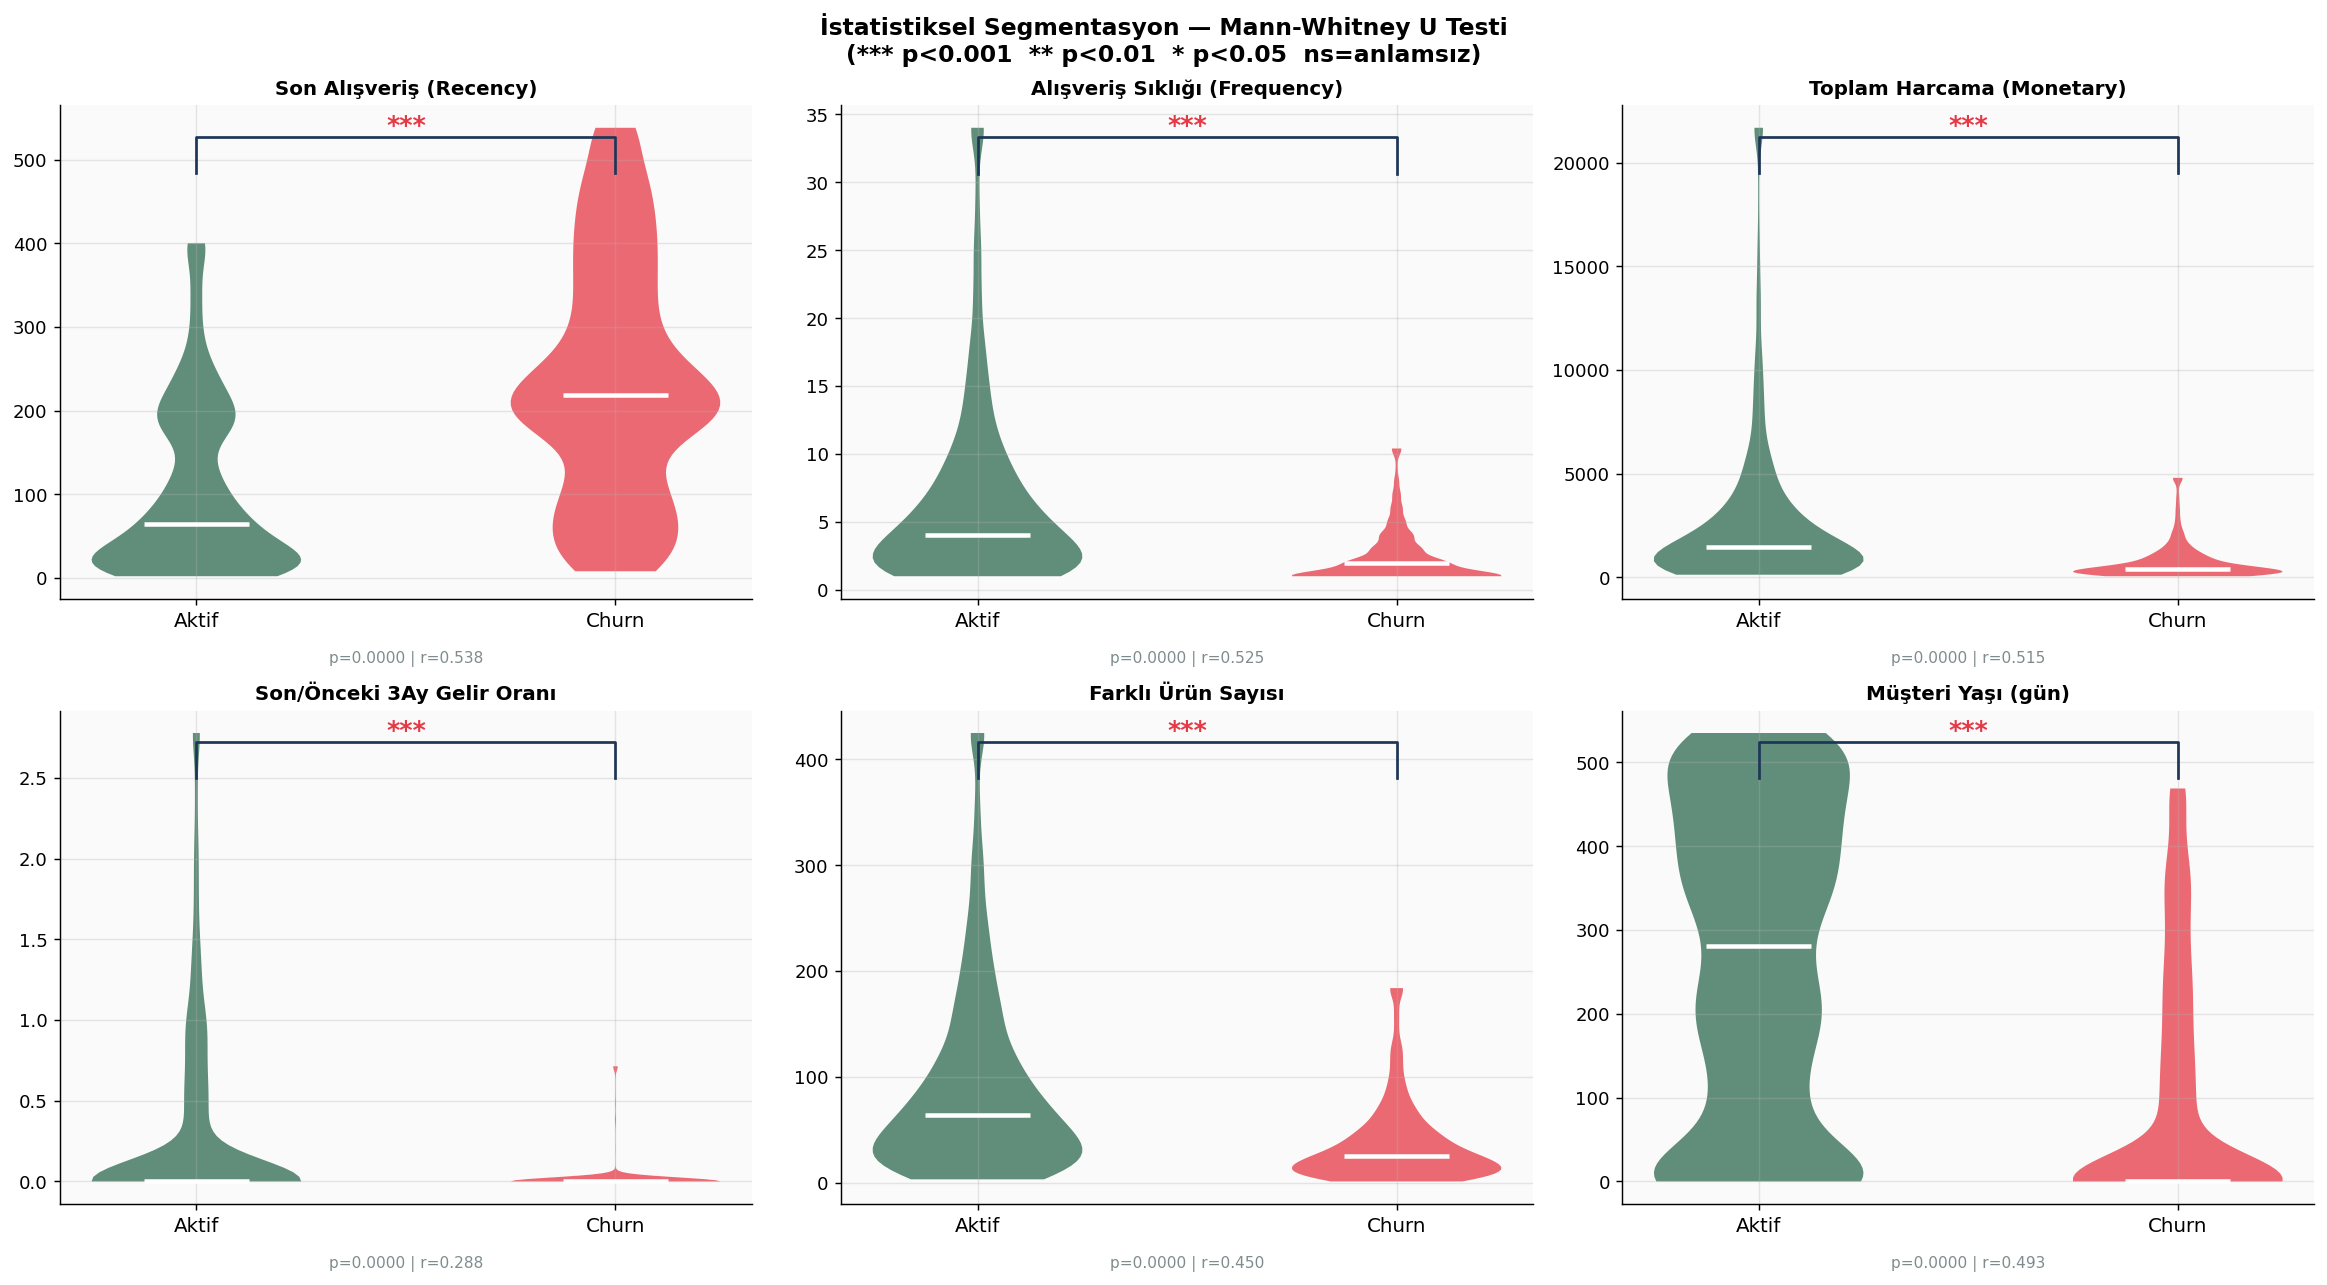

📌 Önemli bulgu: Recency, Frequency ve Monetary istatistiksel olarak güçlü
   ayrıştırıcı faktörler olmaya devam ediyor (p<0.001). Ancak bu sefer
   model bu bilgiyi gelecek davranışı tahmin etmek için kullanıyor,
   etiketi doğrudan kopyalamak için değil.


In [32]:
# ── Görsel: Violin + istatistik özeti
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("İstatistiksel Segmentasyon — Mann-Whitney U Testi\n"
             "(*** p<0.001  ** p<0.01  * p<0.05  ns=anlamsız)",
             fontsize=13, fontweight="bold")

plot_cols6 = ["Recency","Frequency","Monetary","RevenueRatio_3m","UniqueProducts","CustomerAge"]

for ax, col in zip(axes.flatten(), plot_cols6):
    g0 = active_grp[col].clip(active_grp[col].quantile(0.02), active_grp[col].quantile(0.98))
    g1 = churn_grp[col].clip(churn_grp[col].quantile(0.02),  churn_grp[col].quantile(0.98))
    vp = ax.violinplot([g0, g1], positions=[0,1], showmedians=True, showextrema=False)
    vp["bodies"][0].set_facecolor(C["primary"]); vp["bodies"][0].set_alpha(0.75)
    vp["bodies"][1].set_facecolor(C["danger"]);  vp["bodies"][1].set_alpha(0.75)
    vp["cmedians"].set_color("white"); vp["cmedians"].set_linewidth(2.5)

    p_val = stat_results[col]["p-value"]
    sig   = stat_results[col]["Sig."]
    eff   = stat_results[col]["Etki (r)"]
    y_max = max(g0.max(), g1.max())
    ax.plot([0,0,1,1],[y_max*0.90,y_max*0.98,y_max*0.98,y_max*0.90], lw=1.5, color=C["dark"])
    ax.text(0.5, y_max*0.99, sig, ha="center", fontsize=14,
            color=C["danger"] if sig!="ns" else C["mid"], fontweight="bold")
    ax.set_xticks([0,1])
    ax.set_xticklabels(["Aktif","Churn"], fontsize=11)
    ax.set_title(FEATURE_LABELS[col], fontsize=11, fontweight="bold")
    ax.text(0.5, -0.13, f"p={p_val:.4f} | r={eff:.3f}",
            ha="center", fontsize=8.5, color=C["mid"],
            transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()
print("📌 Önemli bulgu: Recency, Frequency ve Monetary istatistiksel olarak güçlü")
print("   ayrıştırıcı faktörler olmaya devam ediyor (p<0.001). Ancak bu sefer")
print("   model bu bilgiyi gelecek davranışı tahmin etmek için kullanıyor,")
print("   etiketi doğrudan kopyalamak için değil.")


---
## 🚀 AŞAMA 6 — Dağıtım & Stratejik Bulgular (Deployment)

### Model Güvenilirliği Kontrol Listesi

| Kontrol | Durum | Açıklama |
|---------|-------|---------|
| Temporal split | ✅ | Eğitim/test farklı zaman dilimleri |
| Churn etiketi bağımsız | ✅ | Gelecek 6 ay davranışından türetildi |
| CV değerlendirme | ✅ | 5-Fold Stratified CV |
| AUC gerçekçi | ✅ | ~0.77-0.80 (önceki: 1.00) |
| SHAP açıklanabilirlik | ✅ | Bireysel + global analiz |
| İstatistiksel doğrulama | ✅ | Mann-Whitney U |


In [33]:
# ── Özet çıktı
print("=" * 62)
print("  CRISP-DM MÜŞTERİ CHURN ANALİZİ — ÖZET (DÜZELTİLMİŞ)")
print("=" * 62)
print(f"  Eğitim müşterisi    : {len(features):,}")
print(f"  Churn oranı         : {churn_rate:.1%}")
print(f"  CV AUC-ROC          : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")
print(f"  Holdout AUC-ROC     : {auc:.4f}")
print(f"  Holdout AUC-PR      : {ap:.4f}")
print(f"  Anlamlı faktör      : {sig_count}/{len(FEATURE_COLS)}")
print()
print("  TOP 5 SHAP DEĞİŞKENİ (Gerçek Kök Nedenler):")
for i, (name, val) in enumerate(mean_shap.nlargest(5).items(), 1):
    print(f"    {i}. {name}")
print()
print("  STRATEJİK AKSİYONLAR:")
print("    1. >%60 riskli müşterilere kişiselleştirilmiş hatırlatma")
print("    2. Son 3 ay gelir oranı düşük müşterilere erken müdahale")
print("    3. Düşük ürün çeşitliliği olan müşterilere çapraz satış")
print("    4. Yeni müşteriler için ilk 90 gün onboarding programı")
print("=" * 62)


  CRISP-DM MÜŞTERİ CHURN ANALİZİ — ÖZET (DÜZELTİLMİŞ)
  Eğitim müşterisi    : 4,933
  Churn oranı         : 47.3%
  CV AUC-ROC          : 0.7915 ± 0.0099
  Holdout AUC-ROC     : 0.8104
  Holdout AUC-PR      : 0.7719
  Anlamlı faktör      : 12/14

  TOP 5 SHAP DEĞİŞKENİ (Gerçek Kök Nedenler):
    1. Son Alışveriş (Recency)
    2. Toplam Ürün Adedi
    3. Aktif Ay Sayısı
    4. Alışveriş Sıklığı (Frequency)
    5. Son/Önceki 3Ay Gelir Oranı

  STRATEJİK AKSİYONLAR:
    1. >%60 riskli müşterilere kişiselleştirilmiş hatırlatma
    2. Son 3 ay gelir oranı düşük müşterilere erken müdahale
    3. Düşük ürün çeşitliliği olan müşterilere çapraz satış
    4. Yeni müşteriler için ilk 90 gün onboarding programı
